In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

In [13]:
# Loading the CSV
# Inspecting
# and Checking Targets

df = pd.read_csv("/home/zea6/Final Project/dataset.csv")

df.head()

print(df.shape)
print(df.columns)
print(df.info())

df["Target"].value_counts()

(4424, 35)
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without e

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [14]:
# Creating Folders and
# defining group features

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

target_col = "Target"

categorical_features = [
    "Marital status",
    "Application mode",
    "Course",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

binary_features = [
    "Daytime/evening attendance",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numeric_features = [
    "Application order",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

all_features = categorical_features + binary_features + numeric_features

print("Number of predictors:", len(all_features))
print("All predictors covered:", set(all_features) == set(df.columns.drop(target_col)))

missing_from_lists = set(df.columns.drop(target_col)) - set(all_features)
extra_in_lists = set(all_features) - set(df.columns.drop(target_col))

print("Missing from feature lists:", missing_from_lists)
print("Extra in feature lists:", extra_in_lists)

Number of predictors: 34
All predictors covered: True
Missing from feature lists: set()
Extra in feature lists: set()


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Class proportions:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: count, dtype: float64


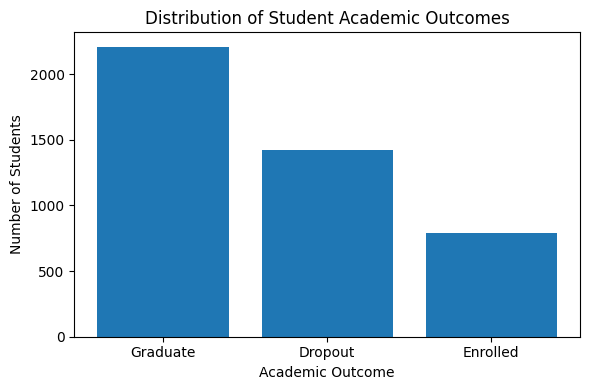

In [15]:
# Target distribution plot
# Gives us the first paper figure

target_counts = df[target_col].value_counts()

print(target_counts)
print("\nClass proportions:")
print((target_counts / len(df)).round(3))

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index, target_counts.values)
plt.title("Distribution of Student Academic Outcomes")
plt.xlabel("Academic Outcome")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=300)
plt.show()

In [16]:
# Train-test split and preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Handles different scikit-learn versions
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", one_hot, categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape after preprocessing:", X_train_processed.shape)
print("Testing shape after preprocessing:", X_test_processed.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training shape after preprocessing: (3539, 234)
Testing shape after preprocessing: (885, 234)

Training target distribution:
Target
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Testing target distribution:
Target
Graduate    442
Dropout     284
Enrolled    159
Name: count, dtype: int64


In [ ]:
# Choose K for K-Means usign Elbow and Silhoutte

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_processed)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_processed, labels))

results_k = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

results_k

# and plotting it

plt.figure(figsize=(6, 4))
plt.plot(results_k["k"], results_k["inertia"], marker="o")
plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("figures/kmeans_elbow.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(results_k["k"], results_k["silhouette_score"], marker="o")
plt.title("Silhouette Score for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig("figures/kmeans_silhouette.png", dpi=300)
plt.show()

In [ ]:
# Use k = 3 because it had the highest silhoutte score
# and biggest drop in the elbow plot from 2 to 3 clusters
# Fit K-Means with k = 3 and visualize cluster with PCA

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_processed)
test_clusters = kmeans.predict(X_test_processed)

print("Training cluster counts:")
print(pd.Series(train_clusters).value_counts().sort_index())

print("\nTesting cluster counts:")
print(pd.Series(test_clusters).value_counts().sort_index())

# and make the PCA cluster visualization

pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_processed)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=train_clusters,
    alpha=0.7
)
plt.title("PCA Projection of K-Means Student Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("figures/pca_clusters.png", dpi=300)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

Cluster outcome counts:


Target,Dropout,Enrolled,Graduate
Cluster,,,
0,557,57,65
1,527,546,1571
2,53,32,131


Cluster outcome percentages:


Target,Dropout,Enrolled,Graduate
Cluster,,,
0,0.820,0.084,0.096
1,0.199,0.207,0.594
2,0.245,0.148,0.606


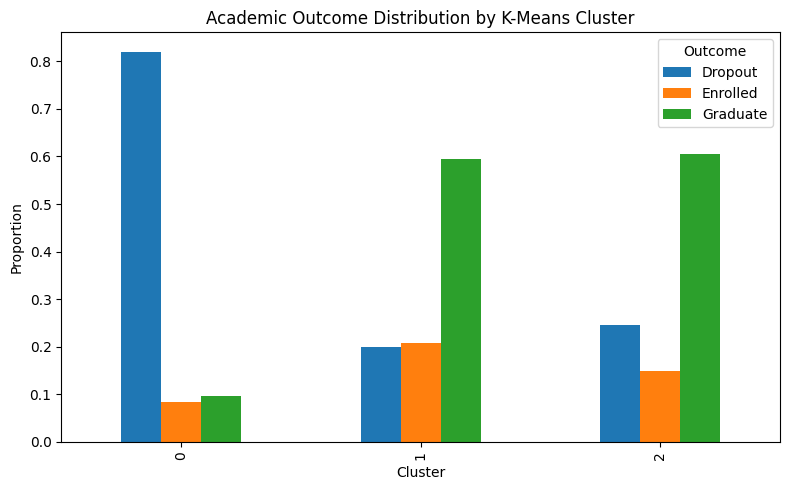

In [23]:
# Analyze how clusters relate to academic outcomes

cluster_analysis = pd.DataFrame({
    "Cluster": train_clusters,
    "Target": y_train.values
})

cluster_counts = pd.crosstab(
    cluster_analysis["Cluster"],
    cluster_analysis["Target"]
)

cluster_percentages = pd.crosstab(
    cluster_analysis["Cluster"],
    cluster_analysis["Target"],
    normalize="index"
).round(3)

print("Cluster outcome counts:")
display(cluster_counts)

print("Cluster outcome percentages:")
display(cluster_percentages)

cluster_percentages.plot(kind="bar", figsize=(8, 5))
plt.title("Academic Outcome Distribution by K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Outcome")
plt.tight_layout()
plt.savefig("figures/cluster_outcome_distribution.png", dpi=300)
plt.show()

In [24]:
# Train baseline supervised model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

def evaluate_model(model, X_train_data, X_test_data, y_train_data, y_test_data):
    model.fit(X_train_data, y_train_data)
    
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)
    
    results = {
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision_macro": precision_score(y_test_data, y_pred, average="macro"),
        "Recall_macro": recall_score(y_test_data, y_pred, average="macro"),
        "F1_macro": f1_score(y_test_data, y_pred, average="macro"),
        "ROC_AUC_ovr": roc_auc_score(y_test_data, y_proba, multi_class="ovr", average="macro")
    }
    
    return results, y_pred, y_proba

baseline_results = {}
baseline_predictions = {}
baseline_probabilities = {}

for name, model in models.items():
    results, y_pred, y_proba = evaluate_model(
        model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
    
    baseline_results[name] = results
    baseline_predictions[name] = y_pred
    baseline_probabilities[name] = y_proba

baseline_results_df = pd.DataFrame(baseline_results).T.round(4)
baseline_results_df

,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC_ovr
Logistic Regression,0.7232,0.6921,0.6964,0.6852,0.8775
Random Forest,0.7605,0.7036,0.6610,0.6698,0.8902
Extra Trees,0.7401,0.6772,0.6332,0.6402,0.8741


In [27]:
# Train cluster-augmented models

from sklearn.preprocessing import OneHotEncoder

try:
    cluster_encoder = OneHotEncoder(sparse_output=False)
except TypeError:
    cluster_encoder = OneHotEncoder(sparse=False)

train_cluster_features = cluster_encoder.fit_transform(train_clusters.reshape(-1, 1))
test_cluster_features = cluster_encoder.transform(test_clusters.reshape(-1, 1))

X_train_cluster_augmented = np.hstack([X_train_processed, train_cluster_features])
X_test_cluster_augmented = np.hstack([X_test_processed, test_cluster_features])

print("Baseline feature shape:", X_train_processed.shape)
print("Cluster-augmented feature shape:", X_train_cluster_augmented.shape)

# and train again

cluster_augmented_results = {}
cluster_augmented_predictions = {}
cluster_augmented_probabilities = {}

for name, model in models.items():
    results, y_pred, y_proba = evaluate_model(
        model,
        X_train_cluster_augmented,
        X_test_cluster_augmented,
        y_train,
        y_test
    )
    
    cluster_augmented_results[name] = results
    cluster_augmented_predictions[name] = y_pred
    cluster_augmented_probabilities[name] = y_proba

cluster_augmented_results_df = pd.DataFrame(cluster_augmented_results).T.round(4)
cluster_augmented_results_df

Baseline feature shape: (3539, 234)
Cluster-augmented feature shape: (3539, 237)


,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC_ovr
Logistic Regression,0.7198,0.6907,0.6925,0.6814,0.8779
Random Forest,0.7605,0.7001,0.6555,0.6626,0.8889
Extra Trees,0.7469,0.6872,0.6419,0.6505,0.8783


In [29]:
# Combined Results into a table

baseline_table = baseline_results_df.copy()
baseline_table.insert(0, "Pipeline", "Baseline")

cluster_table = cluster_augmented_results_df.copy()
cluster_table.insert(0, "Pipeline", "Cluster-Augmented")

final_results = pd.concat([baseline_table, cluster_table])
final_results = final_results.reset_index().rename(columns={"index": "Model"})

display(final_results)

final_results.to_csv("results/model_comparison_results.csv", index=False)

,Model,Pipeline,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC_ovr
0,Logistic Regression,Baseline,0.7232,0.6921,0.6964,0.6852,0.8775
1,Random Forest,Baseline,0.7605,0.7036,0.6610,0.6698,0.8902
2,Extra Trees,Baseline,0.7401,0.6772,0.6332,0.6402,0.8741
3,Logistic Regression,Cluster-Augmented,0.7198,0.6907,0.6925,0.6814,0.8779
4,Random Forest,Cluster-Augmented,0.7605,0.7001,0.6555,0.6626,0.8889
5,Extra Trees,Cluster-Augmented,0.7469,0.6872,0.6419,0.6505,0.8783


In [ ]:
# Save model comparison plot

metric_columns = ["Accuracy", "F1_macro", "ROC_AUC_ovr"]

plot_df = final_results.copy()
plot_df["Model + Pipeline"] = plot_df["Model"] + " (" + plot_df["Pipeline"] + ")"

ax = plot_df.set_index("Model + Pipeline")[metric_columns].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model and Pipeline")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=300)
plt.show()

<Figure size 600x500 with 0 Axes>

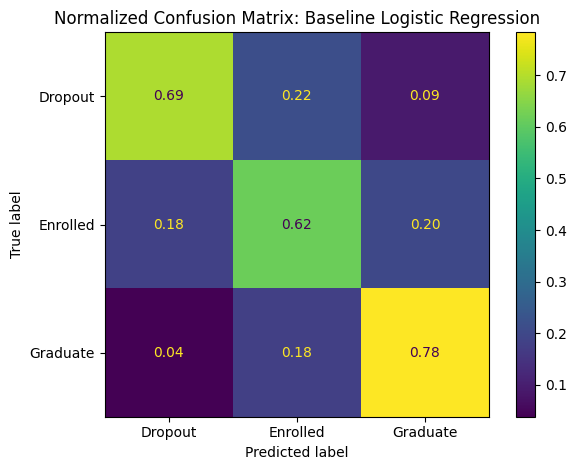

              precision    recall  f1-score   support

     Dropout       0.81      0.69      0.75       284
    Enrolled       0.41      0.62      0.49       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.72       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.72      0.74       885



In [31]:
# Confusion matric for best macro-F1 model
# Since macro F1 matter for imbalanced multiclass
# classification, use Baseline Logistic Regression
# as the main confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

class_order = ["Dropout", "Enrolled", "Graduate"]

best_f1_model_name = "Logistic Regression"
best_f1_predictions = baseline_predictions[best_f1_model_name]

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_f1_predictions,
    labels=class_order,
    normalize="true",
    values_format=".2f"
)
plt.title("Normalized Confusion Matrix: Baseline Logistic Regression")
plt.tight_layout()
plt.savefig("figures/confusion_matrix_logistic_regression.png", dpi=300)
plt.show()

print(classification_report(y_test, best_f1_predictions, labels=class_order))

<Figure size 600x500 with 0 Axes>

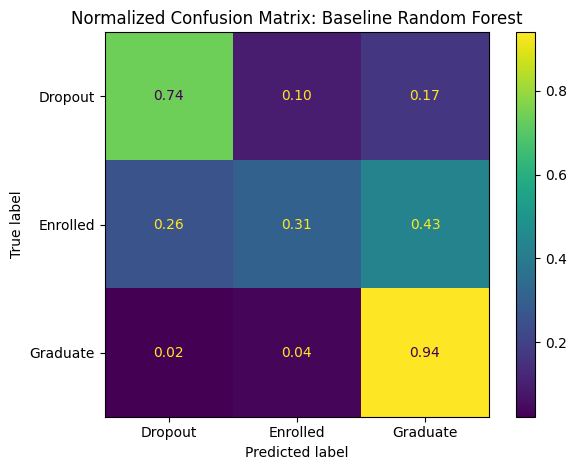

              precision    recall  f1-score   support

     Dropout       0.80      0.74      0.77       284
    Enrolled       0.53      0.31      0.39       159
    Graduate       0.78      0.94      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.66      0.67       885
weighted avg       0.74      0.76      0.74       885



In [32]:
# Confusion Matrix for best accuracy/ROC-AUC model
# gives us a second strong results figure

best_auc_model_name = "Random Forest"
best_auc_predictions = baseline_predictions[best_auc_model_name]

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_auc_predictions,
    labels=class_order,
    normalize="true",
    values_format=".2f"
)
plt.title("Normalized Confusion Matrix: Baseline Random Forest")
plt.tight_layout()
plt.savefig("figures/confusion_matrix_random_forest.png", dpi=300)
plt.show()

print(classification_report(y_test, best_auc_predictions, labels=class_order))

In [ ]:
# Multiclass ROC curves for Random Forest

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

rf_probs = baseline_probabilities["Random Forest"]

y_test_bin = label_binarize(y_test, classes=class_order)

plt.figure(figsize=(7, 5))

for i, class_name in enumerate(class_order):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("One-vs-Rest ROC Curves: Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("figures/roc_curves_random_forest.png", dpi=300)
plt.show()

In [ ]:
# Random Forest feature importance
# This refits a clean Random Forest on 
# the baseline features so we can extract
# feature importances

rf_for_importance = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_for_importance.fit(X_train_processed, y_train)

try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f"feature_{i}" for i in range(X_train_processed.shape[1])]

importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_for_importance.feature_importances_
}).sort_values("Importance", ascending=False)

importances["Feature_clean"] = (
    importances["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("bin__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

top_importances = importances.head(15)

display(top_importances[["Feature_clean", "Importance"]])

plt.figure(figsize=(8, 6))
plt.barh(
    top_importances["Feature_clean"][::-1],
    top_importances["Importance"][::-1]
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/random_forest_feature_importance.png", dpi=300)
plt.show()

importances.to_csv("results/random_forest_feature_importances.csv", index=False)

In [36]:
# Cluster profile table
# This is important to help explain
# what the clusters mean

train_profile_df = X_train.copy()
train_profile_df["Cluster"] = train_clusters
train_profile_df["Target"] = y_train.values

profile_features = [
    "Age at enrollment",
    "Tuition fees up to date",
    "Debtor",
    "Scholarship holder",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

cluster_profiles = train_profile_df.groupby("Cluster")[profile_features].mean().round(3)

cluster_target_percentages = pd.crosstab(
    train_profile_df["Cluster"],
    train_profile_df["Target"],
    normalize="index"
).round(3)

print("Cluster feature profiles:")
display(cluster_profiles)

print("Cluster outcome distribution:")
display(cluster_target_percentages)

cluster_profiles.to_csv("results/cluster_feature_profiles.csv")
cluster_target_percentages.to_csv("results/cluster_outcome_percentages.csv")

Cluster feature profiles:


,Age at enrollment,Tuition fees up to date,Debtor,Scholarship holder,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP
Cluster,,,,,,,,,,,
0,26.099,0.717,0.189,0.103,0.318,1.732,0.085,0.573,11.607,1.344,-0.156
1,22.066,0.921,0.087,0.303,5.259,12.740,5.088,12.472,11.596,1.178,0.063
2,28.778,0.912,0.148,0.111,11.662,12.659,10.093,12.728,11.300,1.379,0.026


Cluster outcome distribution:


Target,Dropout,Enrolled,Graduate
Cluster,,,
0,0.820,0.084,0.096
1,0.199,0.207,0.594
2,0.245,0.148,0.606


In [38]:
# Preparing Tables to be LaTeX-ready: 


In [40]:
# LaTeX-ready result table:

latex_results = final_results.copy()

latex_results = latex_results.rename(columns={
    "Precision_macro": "Macro Precision",
    "Recall_macro": "Macro Recall",
    "F1_macro": "Macro F1",
    "ROC_AUC_ovr": "Macro ROC-AUC"
})

print(latex_results.to_latex(
    index=False,
    float_format="%.4f",
    caption="Performance comparison of baseline and cluster-augmented models on the test set.",
    label="tab:model_results"
))

\begin{table}
\caption{Performance comparison of baseline and cluster-augmented models on the test set.}
\label{tab:model_results}
\begin{tabular}{llrrrrr}
\toprule
Model & Pipeline & Accuracy & Macro Precision & Macro Recall & Macro F1 & Macro ROC-AUC \\
\midrule
Logistic Regression & Baseline & 0.7232 & 0.6921 & 0.6964 & 0.6852 & 0.8775 \\
Random Forest & Baseline & 0.7605 & 0.7036 & 0.6610 & 0.6698 & 0.8902 \\
Extra Trees & Baseline & 0.7401 & 0.6772 & 0.6332 & 0.6402 & 0.8741 \\
Logistic Regression & Cluster-Augmented & 0.7198 & 0.6907 & 0.6925 & 0.6814 & 0.8779 \\
Random Forest & Cluster-Augmented & 0.7605 & 0.7001 & 0.6555 & 0.6626 & 0.8889 \\
Extra Trees & Cluster-Augmented & 0.7469 & 0.6872 & 0.6419 & 0.6505 & 0.8783 \\
\bottomrule
\end{tabular}
\end{table}



In [41]:
# Feature Importance table for LaTeX: 

top_feature_table = top_importances[["Feature_clean", "Importance"]].copy()
top_feature_table = top_feature_table.rename(columns={
    "Feature_clean": "Feature",
    "Importance": "Importance"
})

print(top_feature_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Top 15 Random Forest feature importances.",
    label="tab:feature_importance"
))

\begin{table}
\caption{Top 15 Random Forest feature importances.}
\label{tab:feature_importance}
\begin{tabular}{lr}
\toprule
Feature & Importance \\
\midrule
Curricular units 2nd sem (approved) & 0.0996 \\
Curricular units 2nd sem (grade) & 0.0826 \\
Curricular units 1st sem (grade) & 0.0624 \\
Curricular units 1st sem (approved) & 0.0614 \\
Curricular units 2nd sem (evaluations) & 0.0455 \\
Curricular units 1st sem (evaluations) & 0.0407 \\
Age at enrollment & 0.0401 \\
Tuition fees up to date & 0.0295 \\
GDP & 0.0261 \\
Unemployment rate & 0.0257 \\
Inflation rate & 0.0236 \\
Curricular units 2nd sem (enrolled) & 0.0206 \\
Curricular units 1st sem (enrolled) & 0.0195 \\
Scholarship holder & 0.0167 \\
Application order & 0.0166 \\
\bottomrule
\end{tabular}
\end{table}



In [42]:
# Cluster Profile Tables for LaTeX:

print(cluster_target_percentages.to_latex(
    float_format="%.3f",
    caption="Academic outcome distribution within each K-Means cluster.",
    label="tab:cluster_outcomes"
))

# and 

short_cluster_profiles = cluster_profiles[
    [
        "Age at enrollment",
        "Tuition fees up to date",
        "Debtor",
        "Scholarship holder",
        "Curricular units 1st sem (approved)",
        "Curricular units 2nd sem (approved)",
        "Curricular units 2nd sem (grade)"
    ]
]

print(short_cluster_profiles.to_latex(
    float_format="%.3f",
    caption="Selected feature averages for each K-Means cluster.",
    label="tab:cluster_profiles"
))

\begin{table}
\caption{Academic outcome distribution within each K-Means cluster.}
\label{tab:cluster_outcomes}
\begin{tabular}{lrrr}
\toprule
Target & Dropout & Enrolled & Graduate \\
Cluster &  &  &  \\
\midrule
0 & 0.820 & 0.084 & 0.096 \\
1 & 0.199 & 0.207 & 0.594 \\
2 & 0.245 & 0.148 & 0.606 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Selected feature averages for each K-Means cluster.}
\label{tab:cluster_profiles}
\begin{tabular}{lrrrrrrr}
\toprule
 & Age at enrollment & Tuition fees up to date & Debtor & Scholarship holder & Curricular units 1st sem (approved) & Curricular units 2nd sem (approved) & Curricular units 2nd sem (grade) \\
Cluster &  &  &  &  &  &  &  \\
\midrule
0 & 26.099 & 0.717 & 0.189 & 0.103 & 0.318 & 0.085 & 0.573 \\
1 & 22.066 & 0.921 & 0.087 & 0.303 & 5.259 & 5.088 & 12.472 \\
2 & 28.778 & 0.912 & 0.148 & 0.111 & 11.662 & 10.093 & 12.728 \\
\bottomrule
\end{tabular}
\end{table}



In [44]:
# Check files saved:

import os

print("Saved figures:")
for file in sorted(os.listdir("figures")):
    print(file)

print("\nSaved result files:")
for file in sorted(os.listdir("results")):
    print(file)

Saved figures:
cluster_outcome_distribution.png
confusion_matrix_logistic_regression.png
confusion_matrix_random_forest.png
kmeans_elbow.png
kmeans_silhouette.png
model_comparison.png
pca_clusters.png
random_forest_feature_importance.png
roc_curves_random_forest.png
target_distribution.png

Saved result files:
cluster_feature_profiles.csv
cluster_outcome_percentages.csv
model_comparison_results.csv
random_forest_feature_importances.csv
